# Assignment 4

**Assignment 4: Neural Networks**

**Goal**: ​Get familiar with neural networks by implementing them and applying them to image classification.


**Note**: All assignments are individual, group work and/or the use of generative AI tools for completing the assignments in any capacity and/or copy paste from any resource are considered as plagiarism and reported.

In this assignment we are going to learn about neural networks (NNs). The goal is to implement two neural networks: a fully-connected neural network, a convolutional neural network, and analyze their behavior.

The considered task is image classification. We consider a dataset of small natural images (see the additional file) with multiple classes. We aim at formulating a model (a neural network) and learning it using the negative log-likelihood function (i.e., the cross-entropy loss) as the objective function, and the stochastic gradient descent as the optimizer.

In this assignment, ​**the code must be implemented in PyTorch**.

## 1 Understanding the problem



The considered problem is about classifying images to $L$ classes. In the first part of the assignment, you are asked get familiar with PyTorch, a deep learning library, and the basics of neural networks, and implement neural-network-based classifiers. For this purpose, we will start with classifying small images (8px x 8px) of handwritten digits to one of 10 classes. The dataset is very small and all experiments could be achieved within a couple of minutes.

In the second part, you are asked to implement the whole pipeline for a given dataset by yourself.

Please run the code below and spend a while on analyzing the images.

If any code line is unclear to you, please read on that in numpy, scipy, matplotlib and PyTorch docs.

In [ ]:
import torch
# I use cuda instead of cpu because it works faster
# somewhere I added some strings of code to implement functionality of cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn import datasets
from sklearn.datasets import load_digits
from torch.utils.data import DataLoader, Dataset

EPS = 1.0e-7
# for cuda
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# IF YOU USE COLAB, THIS IS VERY USEFUL! OTHERWISE, PLEASE REMOVE IT.
# mount drive: WE NEED IT FOR SAVING IMAGES!
from google.colab import drive

drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# IF YOU USE COLAB, THIS IS VERY USEFUL! OTHERWISE, PLEASE REMOVE IT.
# PLEASE CHANGE IT TO YOUR OWN GOOGLE DRIVE!
results_dir = "/content/gdrive/My_Drive/Colab Notebooks/"

In [ ]:
# PLEASE DO NOT REMOVE!
# This is a class for the dataset of small (8px x 8px) digits.
# Please try to understand in details how it works!
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode="train", transforms=None):
        digits = load_digits()
        if mode == "train":
            self.data = digits.data[:1000].astype(np.float32)
            self.targets = digits.target[:1000]
        elif mode == "val":
            self.data = digits.data[1000:1350].astype(np.float32)
            self.targets = digits.target[1000:1350]
        else:
            self.data = digits.data[1350:].astype(np.float32)
            self.targets = digits.target[1350:]

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample_x = self.data[idx]
        sample_y = self.targets[idx]
        if self.transforms:
            sample_x = self.transforms(sample_x)
        return (sample_x, sample_y)

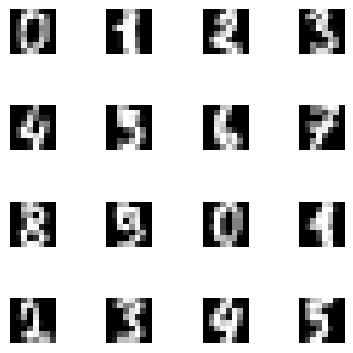

In [ ]:
# PLEASE DO NOT REMOVE
# Here, we plot some images (8px x 8px).
digits = load_digits()
x = digits.data[:16].astype(np.float32)

fig_data, axs = plt.subplots(4, 4, figsize=(4, 4))
fig_data.tight_layout()

for i in range(4):
    for j in range(4):
        img = np.reshape(x[4 * i + j], (8, 8))
        axs[i, j].imshow(img, cmap="gray")
        axs[i, j].axis("off")

## 2 Neural Networks for Digits (4pt)

In this assignment, you are asked to implement a neural network (NN) classifier. Please take a look at the class below and fill in the missing parts.

NOTE: Please pay attention to the inputs and outputs of each function.

### 2.1 Neural Network Classifier

Below, we have two helper modules (layers) that can be used to reshape and flatten a tensor. They are useful for creating sequentials with convolutional layers.

In [ ]:
# PLEASE DO NOT REMOVE!
# Here are two auxiliary functions that can be used for a convolutional NN (CNN).


# This module reshapes an input (matrix -> tensor).
class Reshape(nn.Module):
    def __init__(self, size):
        super(Reshape, self).__init__()
        self.size = size  # a list

    def forward(self, x):
        assert x.shape[1] == np.prod(self.size)
        return x.view(x.shape[0], *self.size)


# This module flattens an input (tensor -> matrix) by blending dimensions
# beyond the batch size.
class Flatten(nn.Module):
    def __init__(self):
        super(Flatten, self).__init__()

    def forward(self, x):
        return x.view(x.shape[0], -1)

Below is the main class for a classifier parameterized by a neural network.

In [ ]:
# =========
# GRADING:
# 0
# 0.5 pt if code works but it is explained badly
# 1.0 pt if code works and it is explained well
# =========
# Implement a neural network (NN) classifier.
class ClassifierNeuralNet(nn.Module):
    def __init__(self, classnet):
        super(ClassifierNeuralNet, self).__init__()
        # We provide a sequential module with layers and activations
        self.classnet = classnet
        # The loss function (the negative log-likelihood)
        self.nll = nn.NLLLoss(reduction="none")  # it requires log-softmax as input!!

    # This function classifies an image x to a class.
    # The output must be a class label (long).
    def classify(self, x):
        # ------
        # PLEASE FILL IN
        '''
        This function classifies an image x to a class.

        self.classnet yields logits (veeery roughly speaking, probabilities but actually they are not):
        for each item in the dataset it produces a tensor with the corresponding classes and non-normalized logits that show whether item is in that class

        torch.argmax returns most likely class (it searches for the highest logit and returns the correspondign class)
        '''

        y_pred = self.classnet(x)
        y_pred = torch.argmax(y_pred, dim=1)

        return y_pred

    # This function is crucial for a module in PyTorch.
    # In our framework, this class outputs a value of the loss function.
    def forward(self, x, y, reduction="avg"):
        '''
        This class outputs a value of the loss function.
        self.nll takes logits from classnet(x), compares them with true classes (y), and calculates the loss-function (negative log-likelihood in our case)
        '''
        # ------
        # PLEASE FILL IN
        loss = self.nll(self.classnet(x), y)
        # ------
        if reduction == "sum":
            return loss.sum()
        else:
            return loss.mean()

**Question 1 (0-0.5pt):** What is the objective function for a classification task? In other words, what is nn.NLLLoss in the code above? Pelase write it in mathematical terms.

**Answer:**  
[from pytorch docs](https://docs.pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)
$$
\ell_n = -w_{y_n}x_{n,y_n}
$$
where $\ell_n$ is a tensor of size $N \times 1$ ($N$ stands for batch size). The most crucial here is $x_{n,y_n}$ which is basically a predicted probability for the true class $y_n$: $x_{n,y_n} = \log p_{n,y_n}$


**Question 2 (0-0.5pt):** In the code above, it is said to use the logarithm of the softmax as the final activation function. Is it correct to use the log-softmax instead of the softmax for making predictions (i.e., picking the most probable label).

**Answer:**  
It should be correct. I mean, applying logarithm function is a monotonic transformation that cannot alter the relative ordering of predicted classes (i.e. no prediction will ever change if we use log-softmax). So, I genuinely suspect that selection of either of them is dependant on architecture and loss function.

### 2.2 Evaluation

In [ ]:
# PLEASE DO NOT REMOVE
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # If available, load the best performing model
    if model_best is None:
        model_best = torch.load(name + ".model",weights_only=False)  # made false from capital letter

    model_best.eval()  # set the model to the evaluation mode
    loss_test = 0.0
    loss_error = 0.0
    N = 0.0
    # start evaluation
    for indx_batch, (test_batch, test_targets) in enumerate(test_loader):
        # for cuda
        test_batch = test_batch.to(device)
        test_targets = test_targets.to(device)

        # loss (nll)
        loss_test_batch = model_best.forward(test_batch, test_targets, reduction="sum")
        loss_test = loss_test + loss_test_batch.item()
        # classification error
        y_pred = model_best.classify(test_batch)
        e = 1.0 * (y_pred == test_targets)
        loss_error = loss_error + (1.0 - e).sum().item()
        # the number of examples
        N = N + test_batch.shape[0]
    # divide by the number of examples
    loss_test = loss_test / N
    loss_error = loss_error / N

    # Print the performance
    if epoch is None:
        print(f"-> FINAL PERFORMANCE: nll={loss_test}, ce={loss_error}")
    else:
        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, val nll={loss_test}, val ce={loss_error}")

    return loss_test, loss_error


# An auxiliary function for plotting the performance curves
def plot_curve(
    name,
    signal,
    file_name="curve.pdf",
    xlabel="epochs",
    ylabel="nll",
    color="b-",
    test_eval=None,
):
    # plot the curve
    plt.plot(
        np.arange(len(signal)), signal, color, linewidth="3", label=ylabel + " val"
    )
    # if available, add the final (test) performance
    if test_eval is not None:
        plt.hlines(
            test_eval,
            xmin=0,
            xmax=len(signal),
            linestyles="dashed",
            label=ylabel + " test",
        )
        plt.text(
            len(signal),
            test_eval,
            "{:.3f}".format(test_eval),
        )
    # set x- and ylabels, add legend, save the figure
    plt.xlabel(xlabel), plt.ylabel(ylabel)
    plt.legend()
    plt.savefig(name + file_name, bbox_inches="tight")
    plt.show()

### 2.3 Training procedure

In [ ]:
# PLEASE DO NOT REMOVE!
# The training procedure
def training(
    name, max_patience, num_epochs, model, optimizer, training_loader, val_loader
):
    nll_val = []
    error_val = []
    best_nll = 1000.0
    patience = 0

    # Main training loop
    for e in range(num_epochs):
        model.train()  # set the model to the training mode
        # load batches
        for indx_batch, (batch, targets) in enumerate(training_loader):
            # for cuda
            batch = batch.to(device)
            targets = targets.to(device)

            # calculate the forward pass (loss function for given images and labels)
            loss = model.forward(batch, targets)
            # remember we need to zero gradients! Just in case!
            optimizer.zero_grad()
            # calculate backward pass
            loss.backward(retain_graph=True)
            # run the optimizer
            optimizer.step()

        # Validation: Evaluate the model on the validation data
        loss_e, error_e = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_e)  # save for plotting
        error_val.append(error_e)  # save for plotting

        # Early-stopping: update the best performing model and break training if no
        # progress is observed.
        if e == 0:
            torch.save(model, name + ".model")
            best_nll = loss_e
        else:
            if loss_e < best_nll:
                torch.save(model, name + ".model")
                best_nll = loss_e
                patience = 0
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    # Return nll and classification error.
    nll_val = np.asarray(nll_val)
    error_val = np.asarray(error_val)

    return nll_val, error_val

### 2.4 Experiments

#### Initialize dataloaders

In [ ]:
# PLEASE DO NOT REMOVE
# Initialize training, validation and test sets.
train_data = Digits(mode="train")
val_data = Digits(mode="val")
test_data = Digits(mode="test")

# Initialize data loaders.
training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
print("How do we get our data from Digits class? \n")
print(f"Feature example: {train_data[1][0]}")
print(f"Feature example shape: {train_data[1][0].shape}")  # i fixed
print(f"Label example: {train_data[1][1]}")

How do we get our data from Digits class? 

Feature example: [ 0.  0.  0. 12. 13.  5.  0.  0.  0.  0.  0. 11. 16.  9.  0.  0.  0.  0.
  3. 15. 16.  6.  0.  0.  0.  7. 15. 16. 16.  2.  0.  0.  0.  0.  1. 16.
 16.  3.  0.  0.  0.  0.  1. 16. 16.  6.  0.  0.  0.  0.  1. 16. 16.  6.
  0.  0.  0.  0.  0. 11. 16. 10.  0.  0.]
Feature example shape: (64,)
Label example: 1


In [ ]:
print("How do we get our data from Pytorch DataLoader class? \n")
train_features, train_labels = next(iter(training_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

print("\n\nWhat happens if we reshape a feature batch? \n")
reshape = Reshape(size=(1, 8, 8))
train_features_reshaped = reshape(train_features)
print(f"Feature batch shape after reshape: {train_features_reshaped.size()}")

print("\n\nWhat happens if we flatten a reshaped feature batch? \n")
flatten = Flatten()
train_features_flattened = flatten(train_features_reshaped)
print(f"Feature batch shape after flatten: {train_features_flattened.size()}")

How do we get our data from Pytorch DataLoader class? 

Feature batch shape: torch.Size([64, 64])
Labels batch shape: torch.Size([64])


What happens if we reshape a feature batch? 

Feature batch shape after reshape: torch.Size([64, 1, 8, 8])


What happens if we flatten a reshaped feature batch? 

Feature batch shape after flatten: torch.Size([64, 64])


#### Initialize hyperparameters

In [ ]:
# PLEASE DO NOT REMOVE
# Hyperparameters
# -> data hyperparams
D = 64  # input dimension

# -> model hyperparams
M = 256  # the number of neurons in scale (s) and translation (t) nets
K = 10  # the number of labels
num_kernels = 32  # the number of kernels for CNN

# -> training hyperparams
lr = 1e-3  # learning rate
wd = 1e-5  # weight decay
num_epochs = 1000  # max. number of epochs
max_patience = 20  # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

#### Running experiments

In the code below, you are supposed to implement architectures for MLP and CNN. For properly implementing these architectures, you can get 0.5pt for each of them.


-> START classifier_mlp
Epoch: 0, val nll=1.356002687726702, val ce=0.26857142857142857
Epoch: 10, val nll=0.14607263020106726, val ce=0.04857142857142857
Epoch: 20, val nll=0.11093222379684448, val ce=0.02857142857142857
Epoch: 30, val nll=0.09518415604318892, val ce=0.025714285714285714
Epoch: 40, val nll=0.09729480385780334, val ce=0.02857142857142857
Epoch: 50, val nll=0.09578519412449428, val ce=0.025714285714285714
Epoch: 60, val nll=0.09662543995039803, val ce=0.022857142857142857
Epoch: 70, val nll=0.10039318799972534, val ce=0.022857142857142857
-> FINAL PERFORMANCE: nll=0.37867048122738833, ce=0.08053691275167785


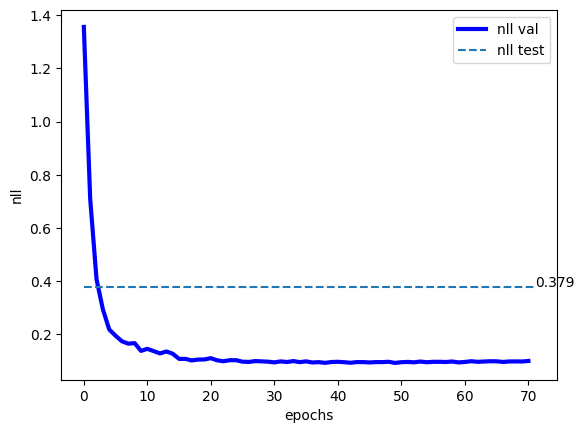

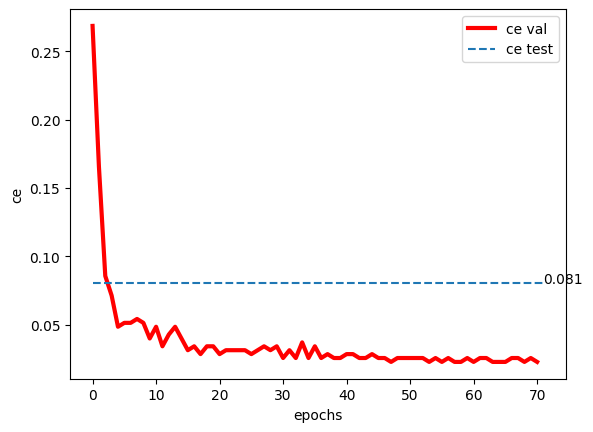


-> START classifier_cnn
Epoch: 0, val nll=1.8514334324428012, val ce=0.3914285714285714
Epoch: 10, val nll=0.11578743934631347, val ce=0.022857142857142857
Epoch: 20, val nll=0.07720084973743983, val ce=0.014285714285714285
Epoch: 30, val nll=0.04697975737707955, val ce=0.011428571428571429
Epoch: 40, val nll=0.03704158101763044, val ce=0.005714285714285714
Epoch: 50, val nll=0.03311083282743182, val ce=0.008571428571428572
Epoch: 60, val nll=0.04246839306184224, val ce=0.011428571428571429
Epoch: 70, val nll=0.02406392880848476, val ce=0.005714285714285714
Epoch: 80, val nll=0.02592556580901146, val ce=0.011428571428571429
Epoch: 90, val nll=0.03794755326850074, val ce=0.008571428571428572
Epoch: 100, val nll=0.021950393297842572, val ce=0.005714285714285714
-> FINAL PERFORMANCE: nll=0.12852810293236036, ce=0.04697986577181208


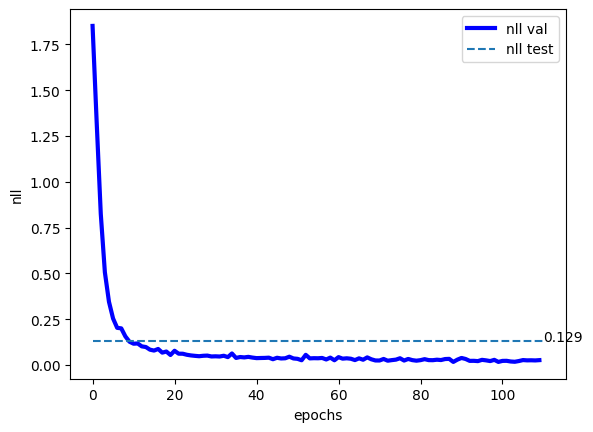

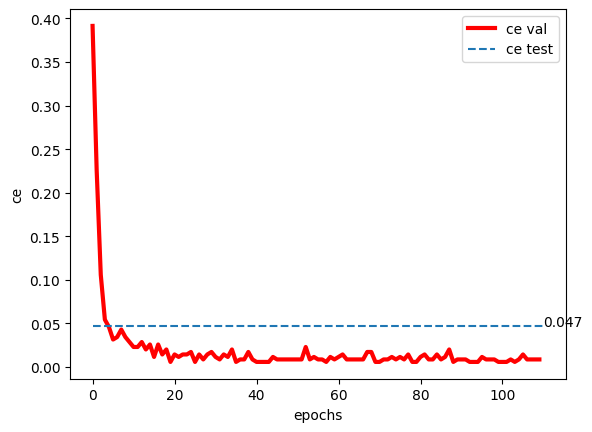

In [ ]:
# PLEASE DO NOT REMOVE and FILL IN WHEN NECESSARY!
# We will run two models: MLP and CNN
names = ["classifier_mlp", "classifier_cnn"]

# loop over models
for name in names:
    print("\n-> START {}".format(name))
    # Create a folder (REMEMBER: You must mount your drive if you use Colab!)
    if name == "classifier_mlp":
        name = name + "_M_" + str(M)
    elif name == "classifier_cnn":
        name = name + "_M_" + str(M) + "_kernels_" + str(num_kernels)

    # Create a folder if necessary
    result_dir = os.path.join(results_dir, "results", name + "/")

    # =========
    # MAKE SURE THAT "result_dir" IS A PATH TO A LOCAL FOLDER OR A GOOGLE COLAB FOLDER (DEFINED IN CELL 3)
    result_dir = "./"  # (current folder)
    # =========
    if not (os.path.exists(result_dir)):
        os.mkdir(result_dir)

    # MLP
    if name[0:14] == "classifier_mlp":
        # =========
        # GRADING:
        # 0
        # 0.5pt if properly implemented
        # =========
        # ------
        # PLEASE FILL IN:
        classnet = nn.Sequential(

            # hidden FC layers, ReLU for non-linearity, and afterwards log-softmax
            nn.Linear(64, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10),
            nn.LogSoftmax(dim=1)
        )
        # You are asked here to propose your own architecture
        # NOTE: Please remember that the output must be LogSoftmax!
        # ------

    # CNN
    elif name[0:14] == "classifier_cnn":
        # =========
        # GRADING:
        # 0
        # 0.5pt if properly implemented
        # =========
        # ------
        # PLEASE FILL IN:
        classnet = nn.Sequential(
            Reshape(size=(1, 8, 8)),

            # two identical (except for adjusted dimensions) blocks (conv2d + non-linearity with ReLU + max-pooling)
            nn.Conv2d(in_channels=1, out_channels=num_kernels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=num_kernels, out_channels=num_kernels*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            Flatten(),
            nn.Dropout(0.4),  # dropout for better learning

            # and two FCs
            nn.Linear(2*num_kernels * 2 * 2, 128),
            nn.ReLU(),

            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )
        #
        # You are asked here to propose your own architecture
        # NOTE: Plese note that the images are represented as vectors, thus, you must
        # use Reshape(size) as the first layer, and Flatten() after all convolutional
        # layers and before linear layers.
        # NOTE: Please remember that the output must be LogSoftmax!
        # ------

    # Init ClassifierNN
    model = ClassifierNeuralNet(classnet)
    model.to(device)  # for exploting cuda

    # Init OPTIMIZER (here we use ADAMAX)
    optimizer = torch.optim.Adamax(
        [p for p in model.parameters() if p.requires_grad == True],
        lr=lr,
        weight_decay=wd,
    )

    model.to(device)

    # Training procedure
    nll_val, error_val = training(
        name=result_dir + name,
        max_patience=max_patience,
        num_epochs=num_epochs,
        model=model,
        optimizer=optimizer,
        training_loader=training_loader,
        val_loader=val_loader,
    )

    # The final evaluation (on the test set)
    test_loss, test_error = evaluation(name=result_dir + name, test_loader=test_loader)
    # write the results to a file
    f = open(result_dir + name + "_test_loss.txt", "w")
    f.write("NLL: " + str(test_loss) + "\nCE: " + str(test_error))
    f.close()
    # create curves
    plot_curve(
        result_dir + name,
        nll_val,
        file_name="_nll_val_curve.pdf",
        ylabel="nll",
        test_eval=test_loss,
    )
    plot_curve(
        result_dir + name,
        error_val,
        file_name="_ca_val_curve.pdf",
        ylabel="ce",
        color="r-",
        test_eval=test_error,
    )

## 2.5 Analysis

**Question 3 (0-0.5pt)**: Please compare the convergence of MLP and CNN in terms of the loss function and the classification error.

**Answer**:  
CNN ends up better: it reaches lower both loss and error, learns faster in early epochs and is more stable near convergence, while the MLP goes on the plateau earlier and generalizes worse.  

**MLP final (test) performance:**  
nll = 0.3787  
ce = 0.0805 >> nearly 8.1% error or 91.9% accuracy.  

**CNN final (test) performance:**  
nll = 0.1285  
ce = 0.0470 >> nearly 4.7% error or 95.3% accuracy.  

**Question 4 (0-0.5pt)**: In general, for a properly picked architectures, a CNN should work better than an MLP. Did you notice that? Why (in general) CNNs are better suited to images than MLPs?

**Answer**:  
Our experiment confirms that. Indeed, CNNs work better than MLP for several reasons. First, they have less parameters, so they are less prone to overfit but nevertheless capture enough features. Second, they mimic the real human vision: due to the local connectivity, neurons connect to small parts of an image, while MLPs connect every pixel to every other (which is absurd if these pixels are located far from each other). Third, CNNs have kernels and each of those is responsible for its detected pattern (somewhat an allocation of responsibilities). Overall, CNNs are more flexible and consider images not as a whole but by parts.

## 3 Application to Street House View Numbers (SVHN) (6pt)

Please repeat (some) of the code in the previous section and apply a bigger convolutional neural network (CNN) to the following dataset:

http://ufldl.stanford.edu/housenumbers/

Please follow the following steps:
1. (1pt) Create appropriate Dataset class. Please remember to use the original training data and test data, and also to create a validation set from the traning data (at least 10% of the training examples). **Do not use extra examples!**
2. (1pt) Implement an architecture that will give at most 0.1 classification error. For instance, see this paper as a reference: https://arxiv.org/pdf/1204.3968.pdf#:~:text=The%20SVHN%20classification%20dataset%20%5B8,set%20of%20more%20difficult%20samples
3. (1pt) Think of an extra component that could improve the performance (e.g., a regularization, specific activation functions).
4. (1pt) Provide a good explanation of the applied architecture and a description of all components.
5. (2pt) Analyze the results.

**Please be very precise, comment your code and provide a comprehensive and clear analysis.**

#### **Creating dataset class**

In [ ]:
import torchvision
import torchvision.transforms as transforms


class SVHN(Dataset):
    '''
    SVHN dataset
    Here we use the original training data and test data, and also to create a validation set from the traning data
    80% training, 20% validation (from training data)
    We also implemented methods __len__ and __getitem__ from Dataset class
    '''

    def __init__(self, mode="train", transforms=None, root="./data"):
      self.transforms = transforms
      self.root = root

      if mode == "train":
          self.dataset = torchvision.datasets.SVHN(root=root, split="train", download=True)
          # first 80% of train for train
          num_total = len(self.dataset)
          num_train = int(0.8 * num_total)
          # NB: here we take indices (not real values) as we take first 80% but not first K values
          self.indices = np.arange(num_train)
      elif mode == "val":
          self.dataset = torchvision.datasets.SVHN(root=root, split="train", download=True)
          # and rest 20% of train for validation
          num_total = len(self.dataset)
          num_train = int(0.8 * num_total)
          # same here but we take an interval [.8, 1.0] of data
          self.indices = np.arange(num_train, num_total)
      else:  # test as it is
          self.dataset = torchvision.datasets.SVHN(root=root, split="test", download=True)
          self.indices = np.arange(len(self.dataset))


    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        sample_x, sample_y = self.dataset[real_idx]
        # sample_x is 32 by 32 by 3 grachten
        if self.transforms:
            sample_x = self.transforms(sample_x)
        return sample_x, sample_y

#### **Applying CNN architecture: First attempt**

In [ ]:
# initializing training, validation and test sets -- super straightforward
train_data = SVHN(mode="train")
val_data = SVHN(mode="val")
test_data = SVHN(mode="test")

# same code as from the part 2
training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
# checking the data sizes
print(f'train: {len(train_data)}')
print(f'validation: {len(val_data)}')
print(f'test: {len(test_data)}')

train: 58605
validation: 14652
test: 26032


In [ ]:
# in the first attempt, we leave all the hyperparameters from the previous running of CNN (in the part 2)
# as it turns out, the neural network works pretty well with these

num_kernels = 32  # the number of kernels for CNN

# -> training hyperparams
lr = 1e-3  # learning rate
wd = 1e-5  # weight decay
num_epochs = 1000  # max. number of epochs
max_patience = 20  # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

**Explanation how CNN architecture below works**  

For the first attempt, we decided to simply increase the number of layers. It follows a standard feature extraction pattern: stacked convolutional blocks for spatial hierarchies, maxpooling for invariance (i.e. preventing failure on shifted/rotated images, and so on), dropout for regularization (to prevent overfitting), and fully connected layers for classification.  

So, in the first block it extracts low-level features, then goes exctracting mid-level features (like patterns and shapes). Atferwards, the number of channels is increased 32 > 64 to capture more complex structures, while pooling reduces overall number of parameters by 4.  

Dropout(0.25) needed as a regularization mechanism (preventing overfitting on training data within conv blocks), followed by flattening before applying FCs.  

 Since fully-connected layers in the classification head do often overfit, we apply heavy dropout(0.5) as a reqularizing tool. Finally, we receive 10 logit-outputs.

In [ ]:
|print("\n-> START {}".format(name))
# Create a folder (REMEMBER: You must mount your drive if you use Colab!)
name = "classifier_cnn"
name = name + "_M_" + str(M) + "_kernels_" + str(num_kernels) + "part3_base"

# Create a folder if necessary
result_dir = os.path.join(results_dir, "results", name + "/")

# =========
# MAKE SURE THAT "result_dir" IS A PATH TO A LOCAL FOLDER OR A GOOGLE COLAB FOLDER (DEFINED IN CELL 3)
result_dir = "./"  # (current folder)
# =========
if not (os.path.exists(result_dir)):
    os.mkdir(result_dir)

# CNN
# the explanation is given above
classnet = nn.Sequential(
    # 1 block of conv
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),  # [batch_size=64,32,16,16]

    # 2 block of conv
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),  # [batch_size=64,64,8,8]

    # dropout for conv and flattening before FC
    nn.Dropout(0.25),
    Flatten(),

    # 2 FC and dropout for regularization
    nn.Linear(64*8*8, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10),

    # extracting logits from log-softmax
    nn.LogSoftmax(dim=1)
)


# Init ClassifierNN
model = ClassifierNeuralNet(classnet).to(device)  # Move model
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=wd)
nll_val, error_val = training(name="svhn_cnn", max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                            training_loader=training_loader, val_loader=val_loader)


-> START classifier_cnn_M_256_kernels_32
Epoch: 0, val nll=0.8893697511098634, val ce=0.25675675675675674
Epoch: 10, val nll=0.28162701843281507, val ce=0.08005733005733005
Epoch: 20, val nll=0.28833679574583193, val ce=0.07077532077532077
Epoch: 30, val nll=0.3317879055599485, val ce=0.06941031941031942


**Evaluating**

-> FINAL PERFORMANCE: nll=0.3864241107432807, ce=0.0754840196681008


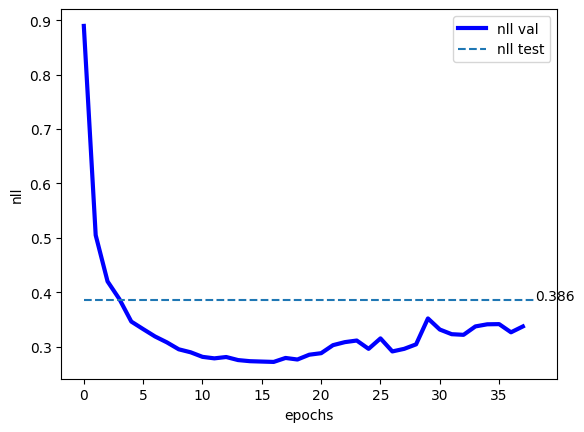

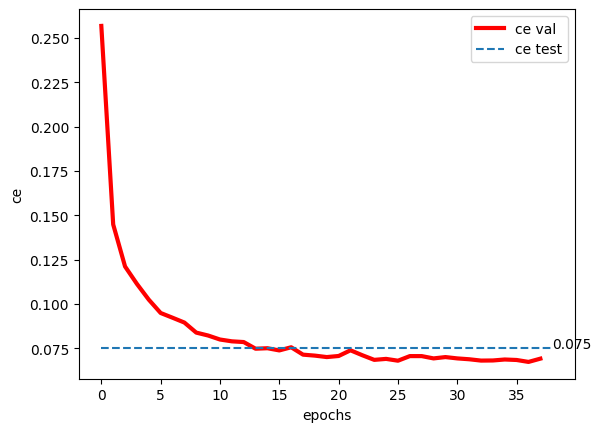

In [ ]:
# The final evaluation (on the test set)
test_loss, test_error = evaluation(test_loader, model_best=model)
# write the results to a file
f = open(result_dir + name + "_test_loss.txt", "w")
f.write("NLL: " + str(test_loss) + "\nCE: " + str(test_error))
f.close()
# create curves
plot_curve(
    result_dir + name,
    nll_val,
    file_name="_nll_val_curve.pdf",
    ylabel="nll",
    test_eval=test_loss,
)
plot_curve(
    result_dir + name,
    error_val,
    file_name="_ca_val_curve.pdf",
    ylabel="ce",
    color="r-",
    test_eval=test_error,
)

**Short analysis**  

Classification error is 0.075 >> accuracy is nearly 0.925  

The final NLL of 0.386 suggests some overfitting (as it rose from earlier around 0.28), but CE stabilized well. Moreover, validation CE improved steadily from 0.257 at epoch 0 to a best of 0.069 around epoch 30, but then rose again.

#### **Applying CNN architecture: Second attempt**

In [ ]:
# here we slightly adjusted some hyperparameters
num_kernels = 32  # the number of kernels for CNN

# -> training hyperparams
lr = 3e-4  # learning rate
wd = 3e-4  # weight decay
num_epochs = 300  # max. number of epochs
max_patience = 50  # an early stopping is used, if training doesn't improve for longer than 50 epochs, it is stopped

**Explanation how this new CNN architecture below works**

This CNN follows almost the same pattern as the previous implementation of CNN (three stacked conv blocks -- one added -- for progressive feature extraction) and heavy dropout in the classifier head to fight overfitting. What else here is batchnorm everywhere for stable training: it makes values more consistent (i.e. the variance and mean becomes more stable what is important when applied to new data).

Block 1 starts with 3 > 32 channels (two convs, 3x3 kernels with padding to keep spatial size), ReLU activations (non-linearity), then maxpool drops height and width from 32 to 16 while building low-level edges/textures.

Block 2 doubles to 64 channels (again two convolutional networks), same ReLU + pooling, now capturing mid-level structures/patterns, pooling to 8x8.

Block 3 adds extra depth: single 64 > 128 conv (fewer parameters but deeper hierarchy), maxpooling to 4x4, extracting high-level digit patterns.

Then we flatten to one long tensor (12844 > 2048 features), dropout(0.5) for preventing overfitting on first 3 blocks.  

FC (2048 > 512 with BN+ReLU), another dropout(0.5), final FC (512 > 10), and finally we apply LogSoftmax.

Overall, deeper than the previous CNN and we implemented normalization! And (spoiler) it works better.

In [ ]:
print("\n-> START {}".format(name))
# Create a folder (REMEMBER: You must mount your drive if you use Colab!)
name = "classifier_cnn"
name = name + "_M_" + str(M) + "_kernels_" + str(num_kernels) + "part3_improved"

# Create a folder if necessary
result_dir = os.path.join(results_dir, "results", name + "/")

# =========
# MAKE SURE THAT "result_dir" IS A PATH TO A LOCAL FOLDER OR A GOOGLE COLAB FOLDER (DEFINED IN CELL 3)
result_dir = "./"  # (current folder)
# =========
if not (os.path.exists(result_dir)):
    os.mkdir(result_dir)

# CNN
classnet = nn.Sequential(
    # block 1: low-level patterns exctracted
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # block 2: mid-level patterns exctracted
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # block 3 (extra depth): higher-level patterns exctracted
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    # flattening before FC and first dropout
    Flatten(),
    nn.Dropout(0.5),

    # two FC (+ BN, ReLU and heavy Dropout)
    nn.Linear(128*4*4, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),

    # receiving logits
    nn.Linear(512, 10),
    nn.LogSoftmax(1)
)


# initialization of CNN
model = ClassifierNeuralNet(classnet).to(device)  # for cuda
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=wd)
nll_val, error_val = training(
    name="svhn_cnn",
    max_patience=max_patience,
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    training_loader=training_loader,
    val_loader=val_loader
    )


-> START classifier_cnn_M_256_kernels_32
Epoch: 0, val nll=0.5508941104429653, val ce=0.16025116025116026
Epoch: 10, val nll=0.2363112942462341, val ce=0.07145782145782145
Epoch: 20, val nll=0.21263867890838062, val ce=0.06162981162981163
Epoch: 30, val nll=0.21673037190678796, val ce=0.06156156156156156
Epoch: 40, val nll=0.21569859552767445, val ce=0.05835380835380835
Epoch: 50, val nll=0.22911944033472778, val ce=0.06006006006006006
Epoch: 60, val nll=0.23303678554490131, val ce=0.06046956046956047
Epoch: 70, val nll=0.23960303663882015, val ce=0.05951405951405951


**Evaluating**

-> FINAL PERFORMANCE: nll=0.2472166806521248, ce=0.06265365703749232


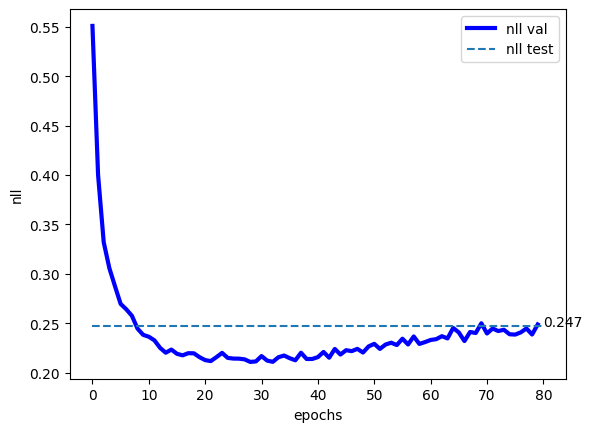

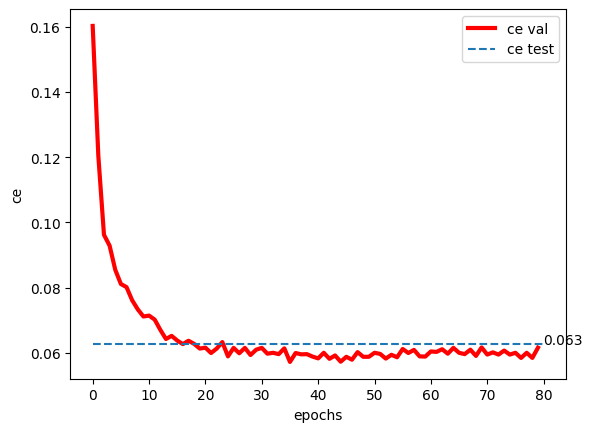

In [ ]:
# The final evaluation (on the test set)
test_loss, test_error = evaluation(test_loader, model_best=model)
# write the results to a file
f = open(result_dir + name + "_test_loss.txt", "w")
f.write("NLL: " + str(test_loss) + "\nCE: " + str(test_error))
f.close()
# create curves
plot_curve(
    result_dir + name,
    nll_val,
    file_name="_nll_val_curve.pdf",
    ylabel="nll",
    test_eval=test_loss,
)
plot_curve(
    result_dir + name,
    error_val,
    file_name="_ca_val_curve.pdf",
    ylabel="ce",
    color="r-",
    test_eval=test_error,
)

**Short analysis**

Classification error is 0.062 >> accuracy is around 0.937

Validation CE dropped from 0.160 at epoch 0 to 0.071 by epoch 10, then steadily improved to a low of 0.058 around epoch 40. Then it stabilized between 0.058-0.060 through epoch 70. It probably indicates robust learning without major degradation. NLL behaved almost the same, however it went up from epoch 40, so it looks like a slight overfitting.

#### **Overall analysis on SVHN problem solutions**

small analyses can be found after each CNN evaluation section independently

Second CNN outperforms the first on validation metrics, due to added depth (3 conv blocks instead of 2), BatchNorm stabilization, and stronger regularization (two `dropout(0.5)` instead of `dropout(0.25)`+`dropout(0.5)` in the first one).  

Final CE drops from `0.075` to `0.063` (around `16%` relative gain, `92.5%` to `93.7%` accuracy).  

The reasons are straightforward: the deeper CNN with strong regularization mechanisms preventing it from overfitting is, the better performance is. Moreover, BatchNormalization after every conv stabilizes gradients for faster and smoother convergence (you may notice the lower starting CE (0.160 vs 0.257) and quicker drop to less than 0.07 by epoch 10).  

Probably, some additional methods could help to gain a better CE rates: more training data (through augmentation process), more hidden layers or some adjustments in architecture.